# Analisis de Cancer

Lucho Ene / Jan | 2024 <br>
Gone gone gone by Phillip Phillip


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats
from math import pi
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (confusion_matrix, roc_curve, auc, classification_report, accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout

from sklearn.model_selection import train_test_split



## Import Datasets

In [ ]:
#Carga del dataset y eliminar el que no sirve
df = pd.read_csv(r"data_breast_cancer.csv")drop(columns=['Unnamed: 32'],errors='ignore')
df_raw = df.copy()
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.shape

(569, 32)

In [4]:
df.duplicated().sum()

0

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [8]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [9]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

### Analisis Exploratorio de Datos (EDA)

<Axes: xlabel='count', ylabel='diagnosis'>

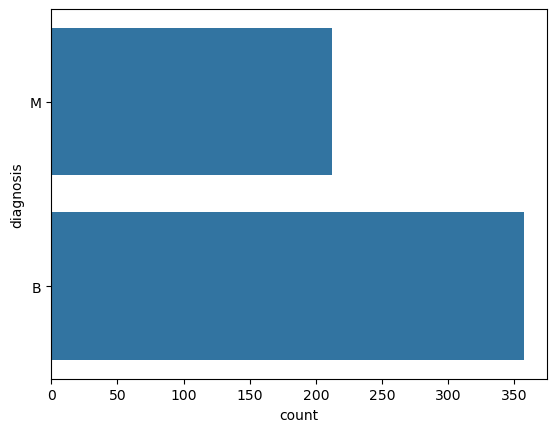

In [10]:
sns.countplot(df["diagnosis"], label = "count")

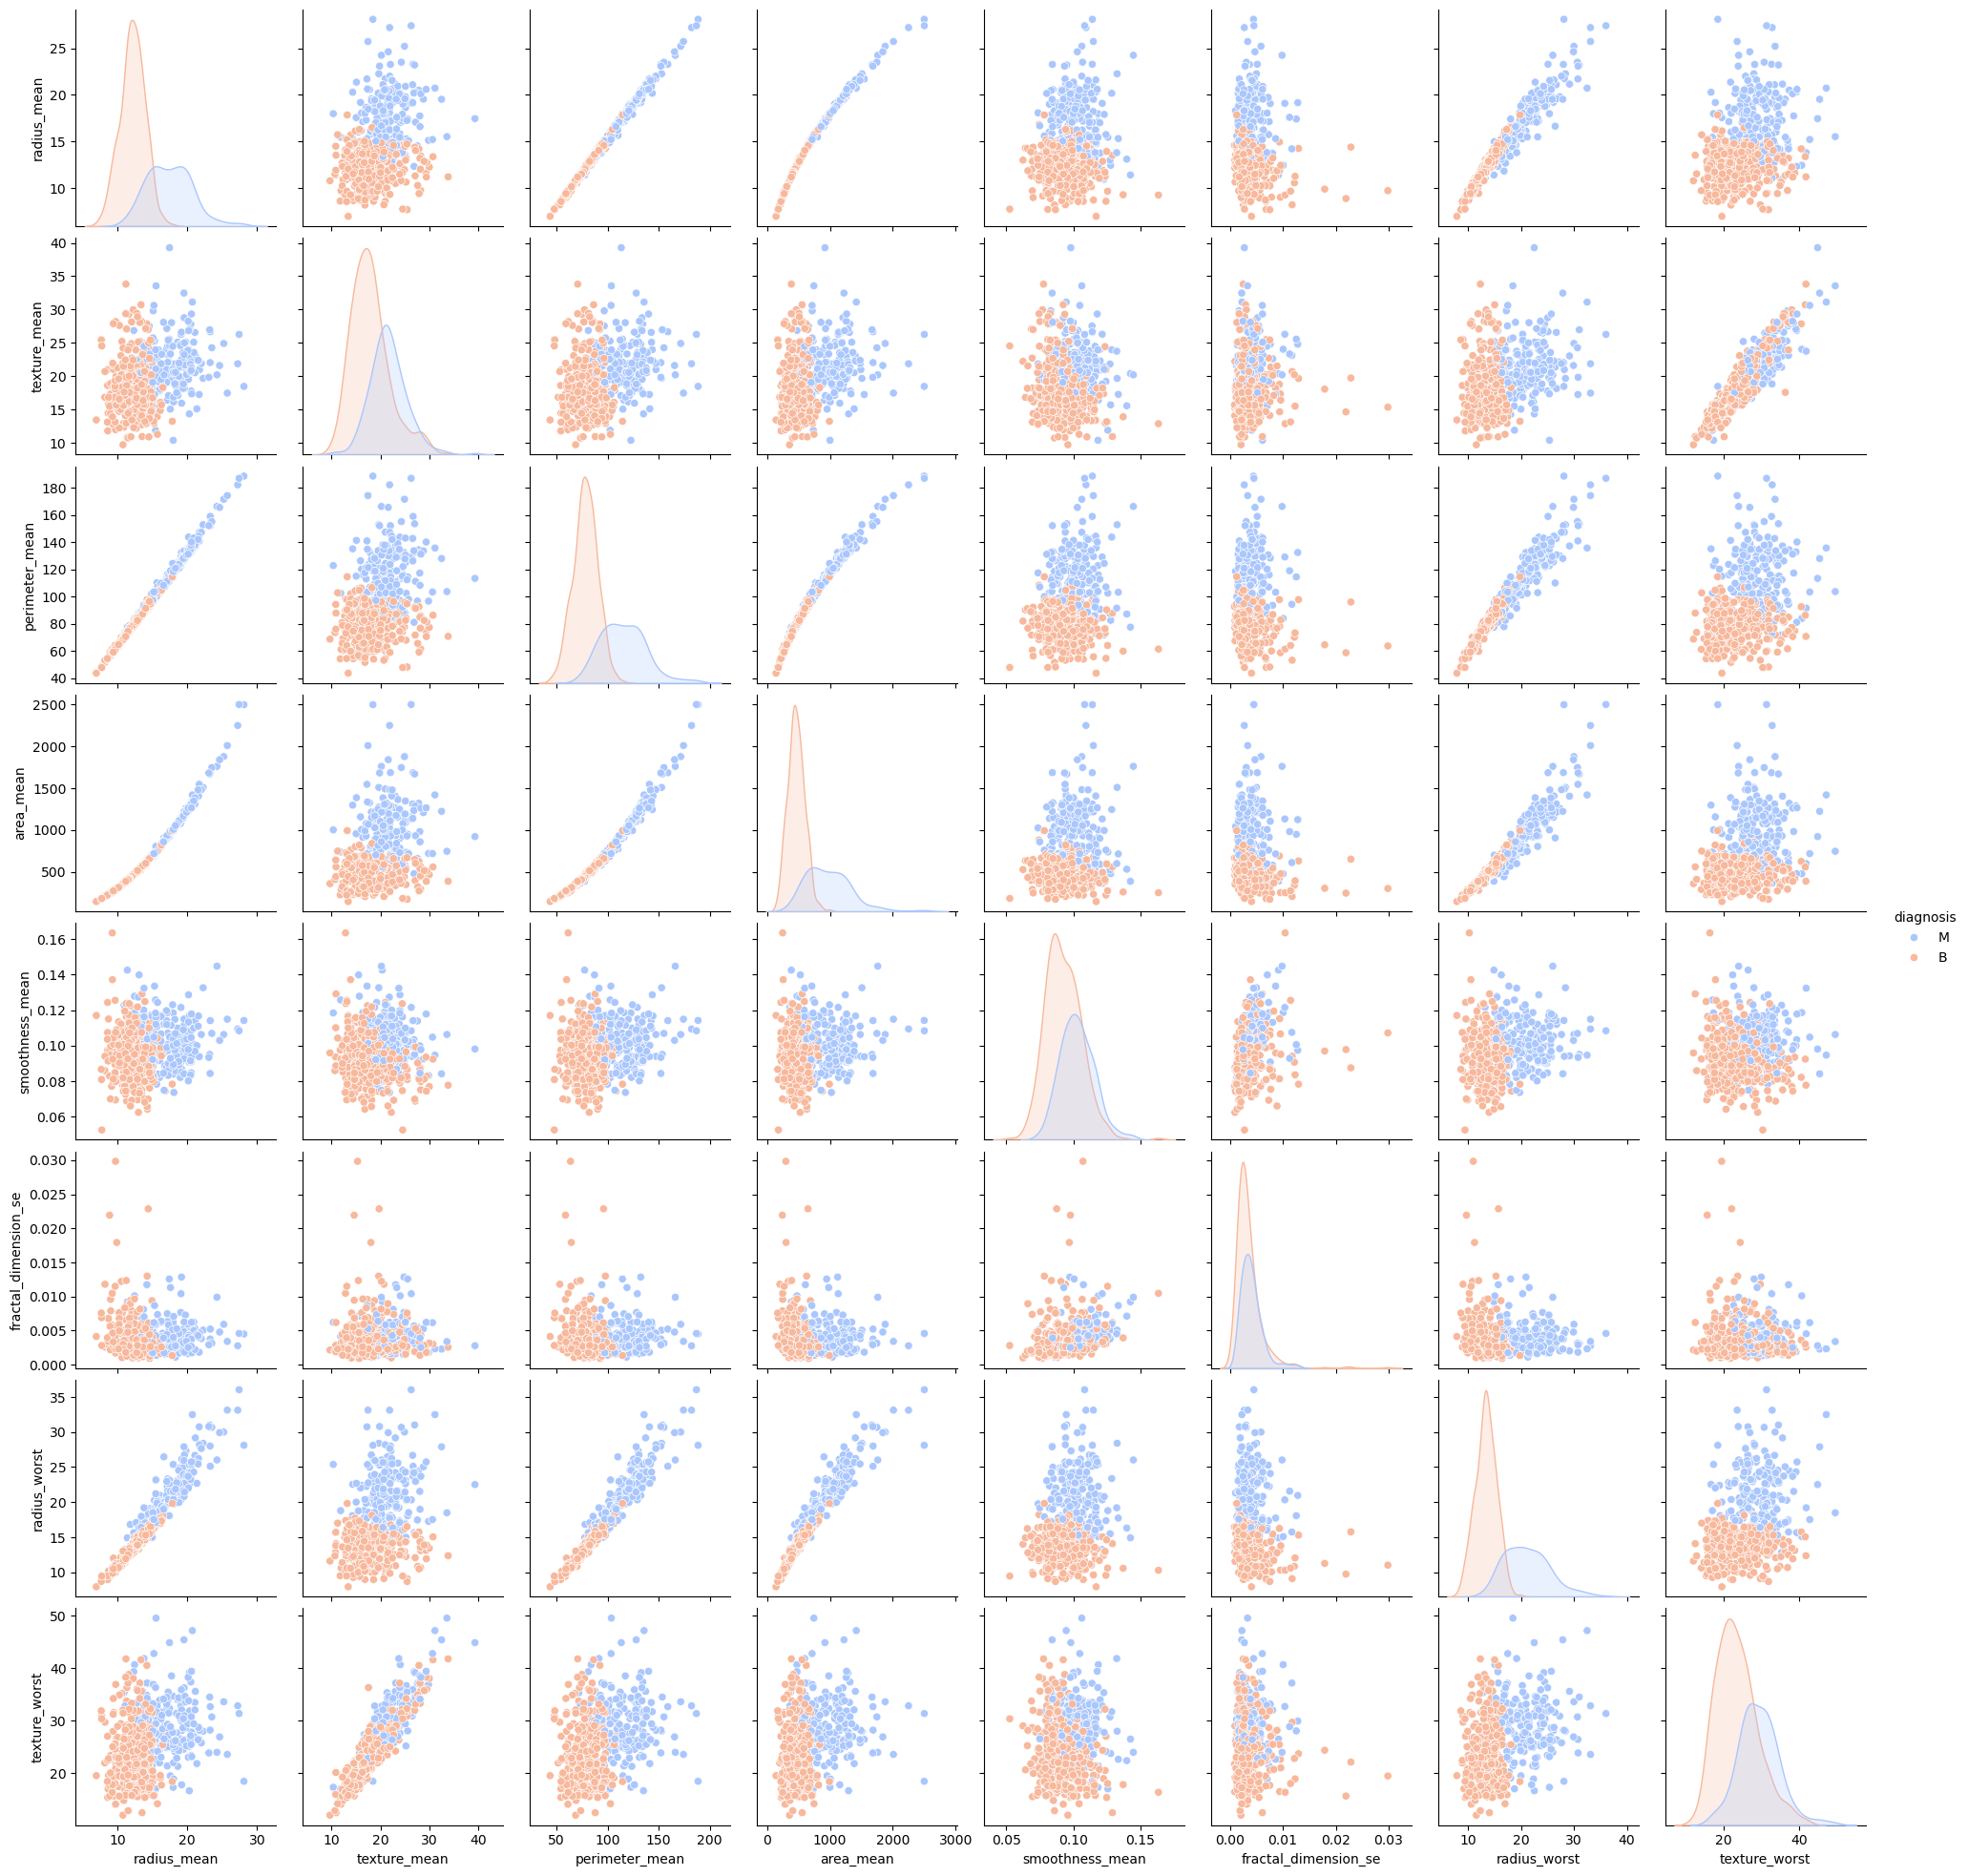

In [11]:
sns.pairplot(df,hue = 'diagnosis', palette= 'coolwarm', vars = ['radius_mean', 'texture_mean', 'perimeter_mean','area_mean','smoothness_mean','fractal_dimension_se', 'radius_worst', 'texture_worst',])

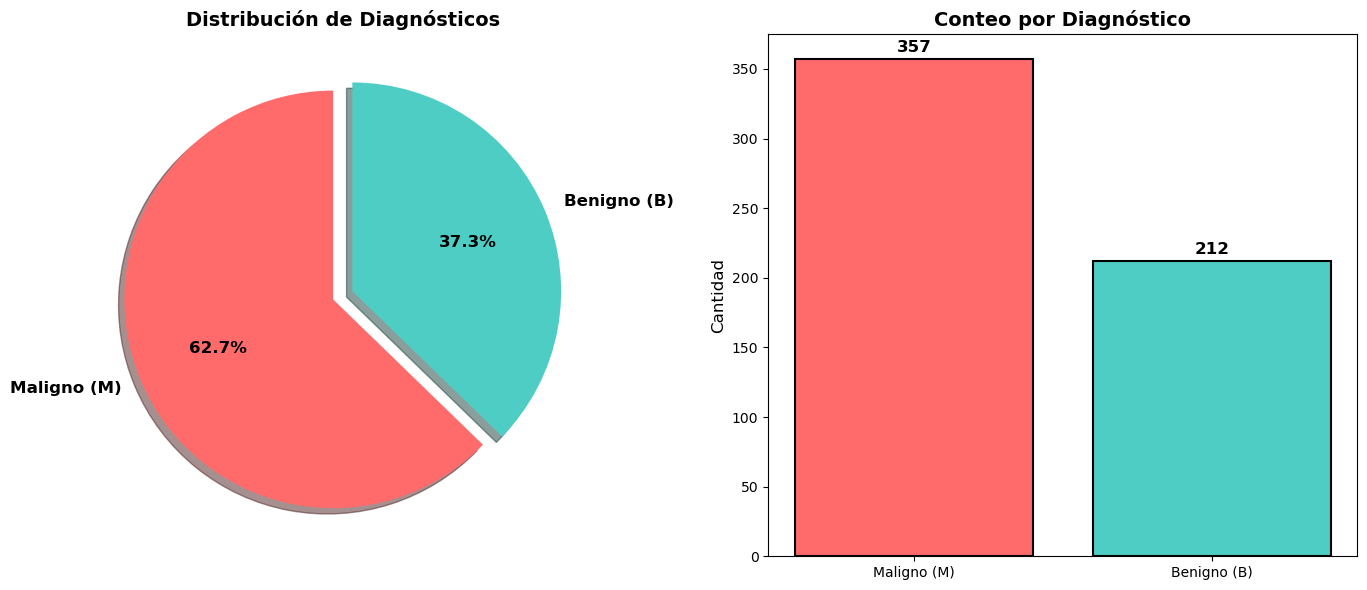

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de pastel
colors = ['#ff6b6b', '#4ecdc4']
diagnosis_counts = df['diagnosis'].value_counts()
explode = (0.05, 0.05)

axes[0].pie(diagnosis_counts.values,  labels=['Maligno (M)', 'Benigno (B)'], autopct='%1.1f%%',colors=colors,explode=explode, shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Distribución de Diagnósticos', fontsize=14, fontweight='bold')

# Gráfico de barras
bars = axes[1].bar(['Maligno (M)', 'Benigno (B)'], diagnosis_counts.values, color=colors,edgecolor='black',linewidth=1.5)
axes[1].set_title('Conteo por Diagnóstico', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cantidad', fontsize=12)

# Agregar valores en las barras
for bar, val in zip(bars, diagnosis_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Analisis de caracteristicas de cada diagnostico

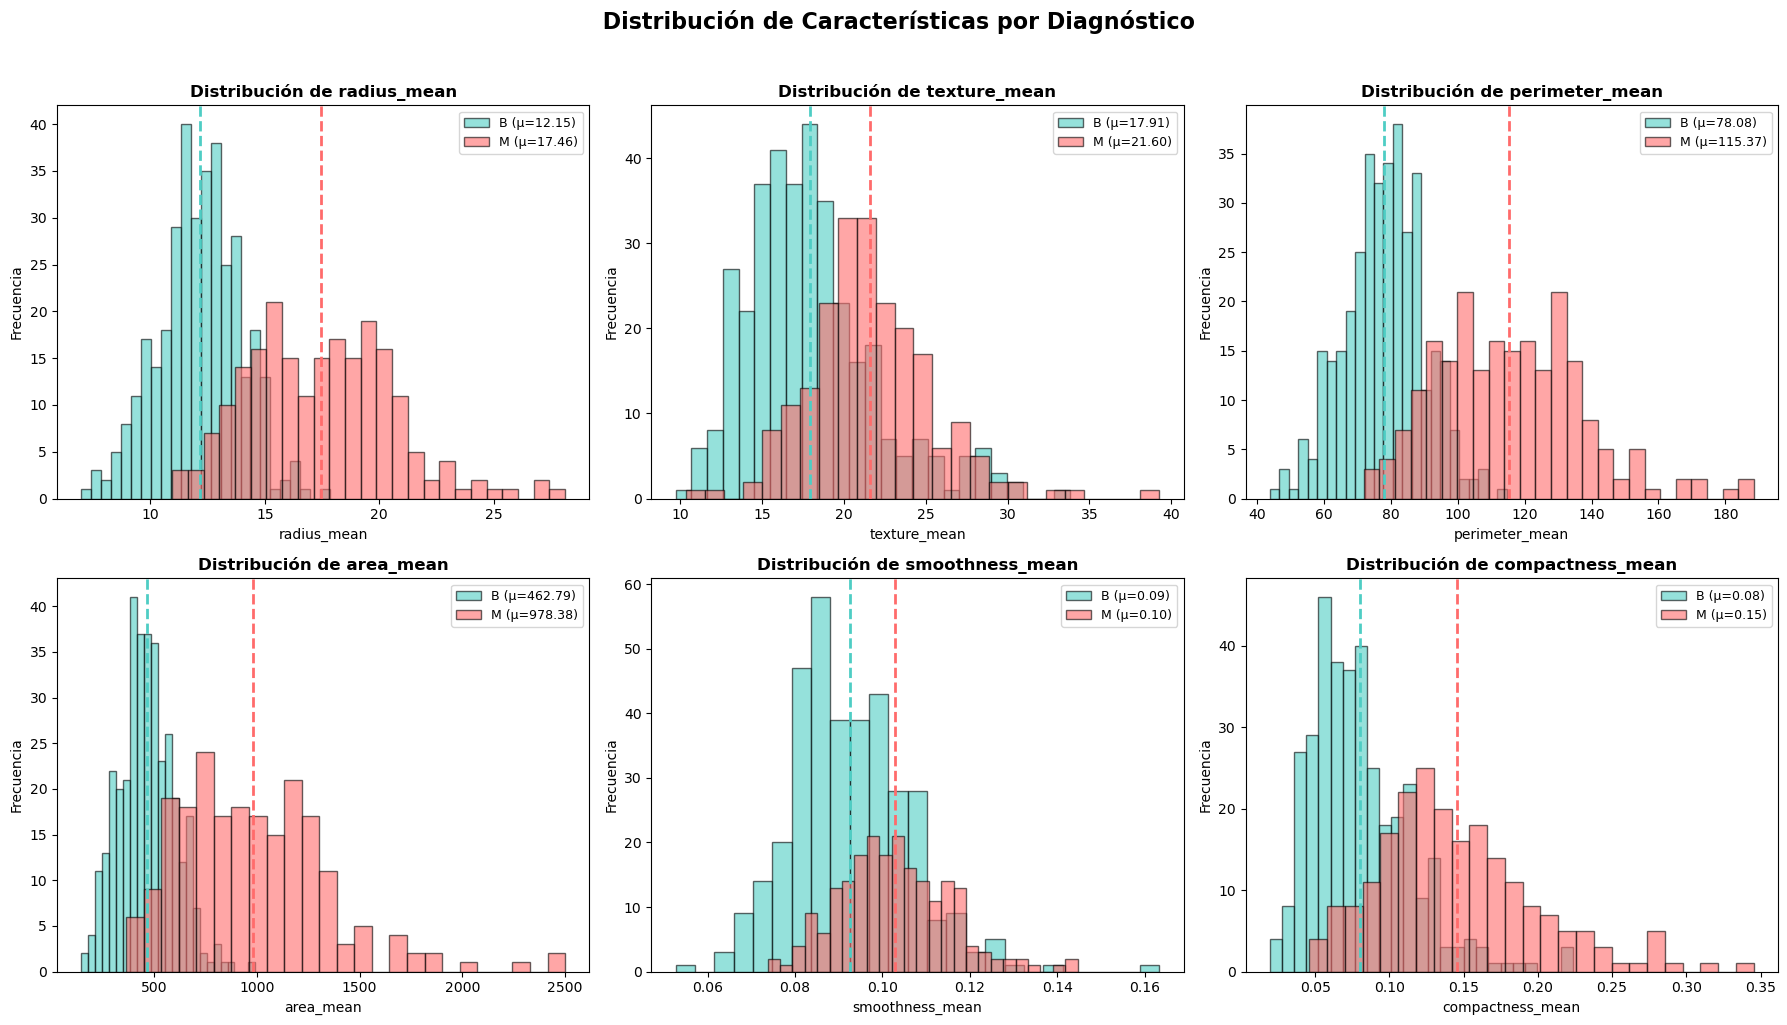


Test t de Student para diferencias entre grupos
------------------------------------------------------------
radius_mean              : t= -25.436, p=8.47e-96 ***
texture_mean             : t= -10.867, p=4.06e-25 ***
perimeter_mean           : t= -26.405, p=8.44e-101 ***
area_mean                : t= -23.939, p=4.73e-88 ***
smoothness_mean          : t=  -9.146, p=1.05e-18 ***
compactness_mean         : t= -17.698, p=3.94e-56 ***


In [13]:
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
                    'smoothness_mean', 'compactness_mean']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    for diagnosis, color in zip(['B', 'M'], ['#4ecdc4', '#ff6b6b']):
        subset = df[df['diagnosis'] == diagnosis][feature]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, 
                     label=f'{diagnosis} (μ={subset.mean():.2f})', edgecolor='black')
    
    axes[i].set_title(f'Distribución de {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].axvline(df[df['diagnosis']=='B'][feature].mean(), 
                    color='#4ecdc4', linestyle='--', linewidth=2)
    axes[i].axvline(df[df['diagnosis']=='M'][feature].mean(), 
                    color='#ff6b6b', linestyle='--', linewidth=2)

plt.suptitle(' Distribución de Características por Diagnóstico', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Test estadístico
print("\nTest t de Student para diferencias entre grupos")
print("-" * 60)
for feature in features_to_plot:
    b_data = df[df['diagnosis']=='B'][feature]
    m_data = df[df['diagnosis']=='M'][feature]
    t_stat, p_value = stats.ttest_ind(b_data, m_data)
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{feature:25s}: t={t_stat:8.3f}, p={p_value:.2e} {sig}")

Analisis Discriminativos de los datos

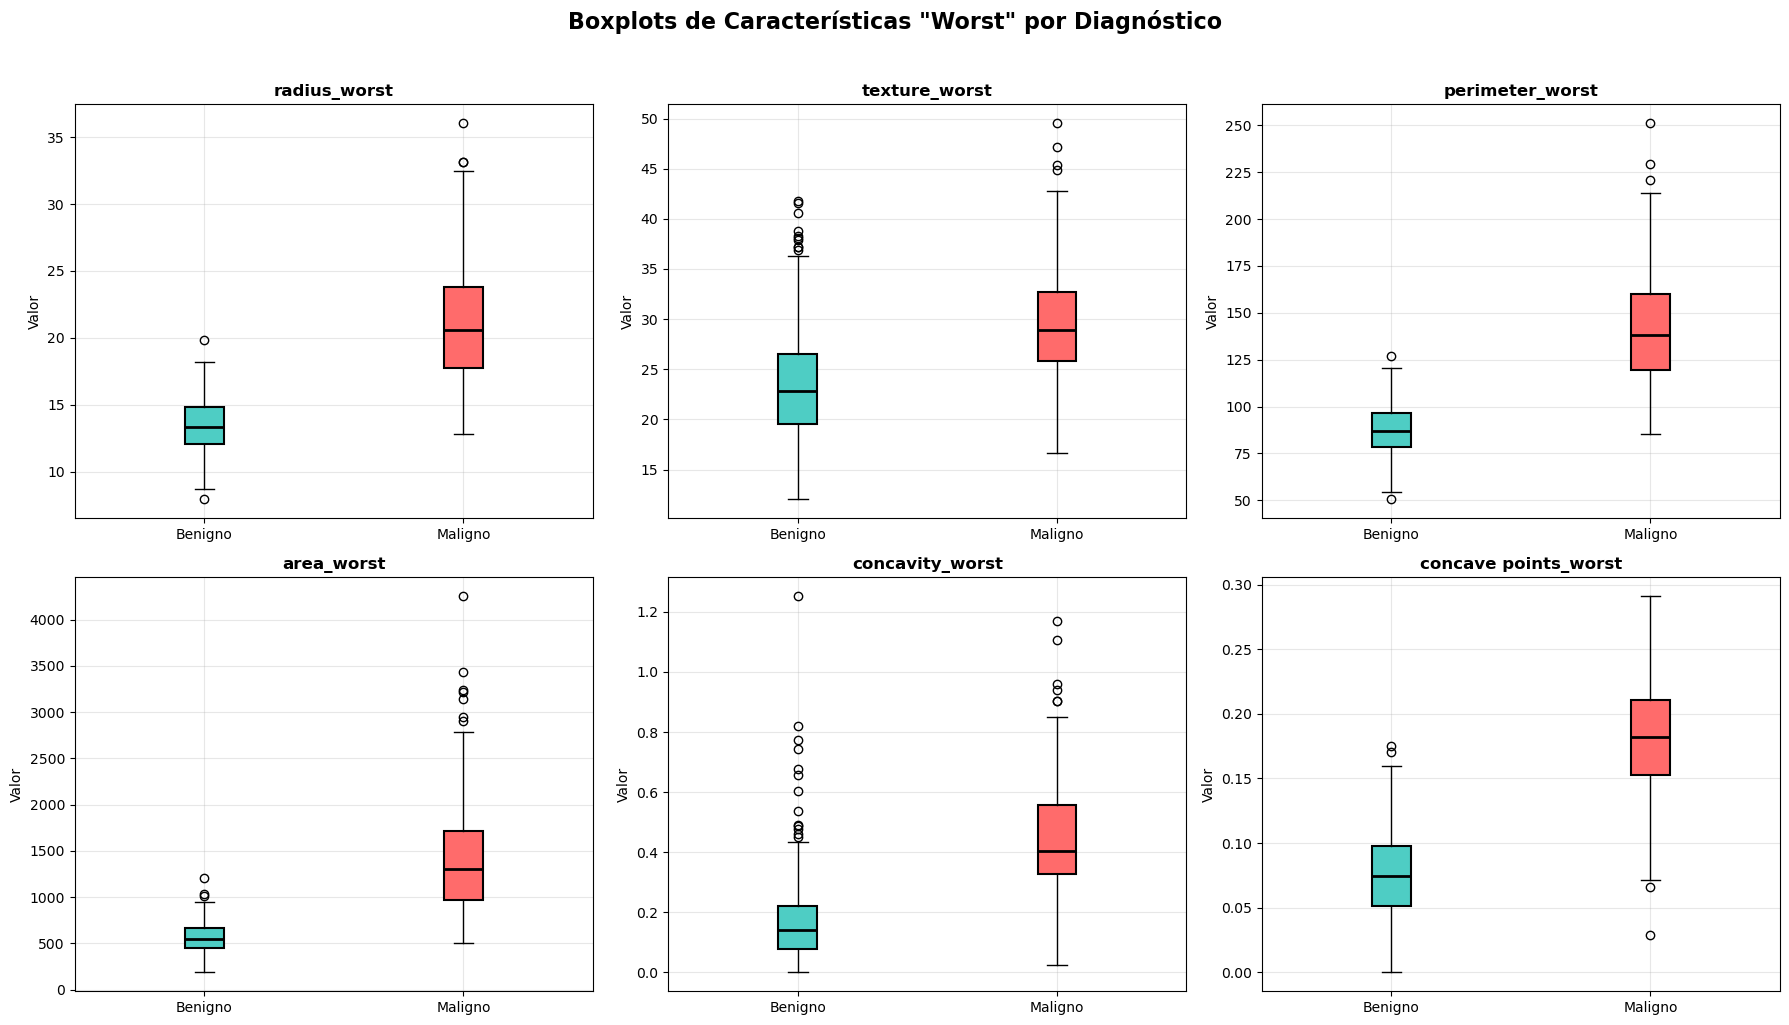


Separación entre grupos (d de Cohen)
------------------------------------------------------------
radius_worst             : d de Cohen = 2.324 (Grande)
texture_worst            : d de Cohen = 1.062 (Grande)
perimeter_worst          : d de Cohen = 2.372 (Grande)
area_worst               : d de Cohen = 1.970 (Grande)
concavity_worst          : d de Cohen = 1.753 (Grande)
concave points_worst     : d de Cohen = 2.604 (Grande)


In [14]:
worst_features = ['radius_worst', 'texture_worst', 'perimeter_worst', 
                  'area_worst', 'concavity_worst', 'concave points_worst']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(worst_features):
    data_to_plot = [df[df['diagnosis']=='B'][feature], 
                    df[df['diagnosis']=='M'][feature]]
    
    bp = axes[i].boxplot(data_to_plot, labels=['Benigno', 'Maligno'],
                         patch_artist=True,
                         boxprops=dict(linewidth=1.5),
                         medianprops=dict(color='black', linewidth=2))
    
    bp['boxes'][0].set_facecolor('#4ecdc4')
    bp['boxes'][1].set_facecolor('#ff6b6b')
    
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valor', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots de Características "Worst" por Diagnóstico', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Calcular separación entre grupos
print("\nSeparación entre grupos (d de Cohen)")
print("-" * 60)
for feature in worst_features:
    b_data = df[df['diagnosis']=='B'][feature]
    m_data = df[df['diagnosis']=='M'][feature]
    pooled_std = np.sqrt((b_data.std()**2 + m_data.std()**2) / 2)
    cohens_d = abs(b_data.mean() - m_data.mean()) / pooled_std
    print(f"{feature:25s}: d de Cohen = {cohens_d:.3f} ({'Grande' if cohens_d > 0.8 else 'Mediano' if cohens_d > 0.5 else 'Pequeño'})")

Los boxplots confirman que las 6 características "worst" separan claramente los tumores benignos de los malignos, siendo concave points_worst y concavity_worst las más discriminantes y texture_worst la menos útil, con los malignos mostrando distribuciones más amplias, asimétricas y con más outliers — lo cual valida la elección de estas variables para el modelo de red neuronal y explica visualmente tanto su alto rendimiento como sus 2 únicos errores en la zona de solapamiento. <br>
El análisis con d de Cohen confirma cuantitativamente lo que los boxplots mostraban visualmente: 5 de las 6 características "worst" tienen efecto "muy grande" (d > 1.7), con concave points_worst liderando (d ≈ 2.06), mientras que texture_worst tiene efecto "grande pero con solapamiento" (d ≈ 0.98) — lo que explica el alto rendimiento del modelo y por qué los únicos 2 errores provienen de casos limítrofes en esa zona de solapamiento.

Analisis de mapa de calor

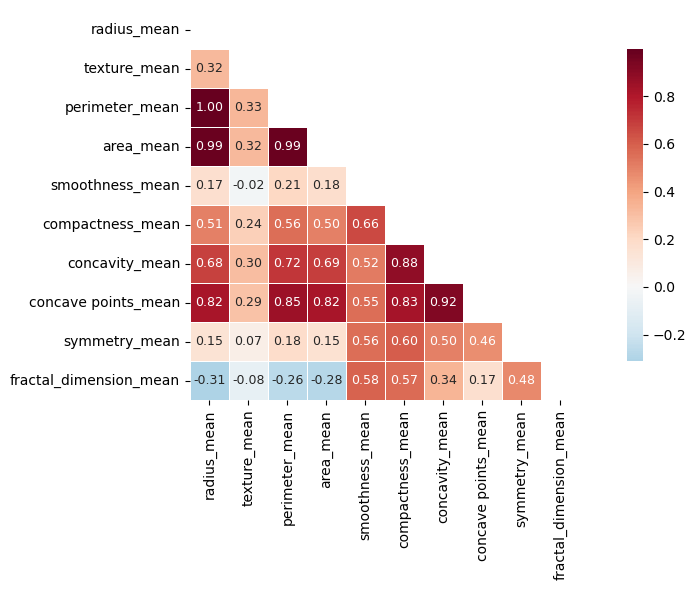


HIPÓTESIS 4: Pares con correlación > 0.9
------------------------------------------------------------
radius_mean          - perimeter_mean      : r = 0.9979
radius_mean          - area_mean           : r = 0.9874
perimeter_mean       - area_mean           : r = 0.9865
concavity_mean       - concave points_mean : r = 0.9214


In [15]:
# Seleccionar características mean
mean_features = [col for col in df.columns if 'mean' in col]
corr_matrix = df[mean_features].corr()

fig, ax = plt.subplots(figsize=(10, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask,annot=True, fmt='.2f', cmap='RdBu_r',center=0,square=True,
            linewidths=0.5,cbar_kws={'shrink': 0.8}, ax=ax,annot_kws={'size': 9})


plt.tight_layout()
plt.show()

# Identificar pares altamente correlacionados
print("\nHIPÓTESIS 4: Pares con correlación > 0.9")
print("-" * 60)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append((corr_matrix.columns[i], 
                             corr_matrix.columns[j], 
                             corr_matrix.iloc[i, j]))
            
for pair in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"{pair[0]:20s} - {pair[1]:20s}: r = {pair[2]:.4f}")

Grafico de Dispersion (PCA)

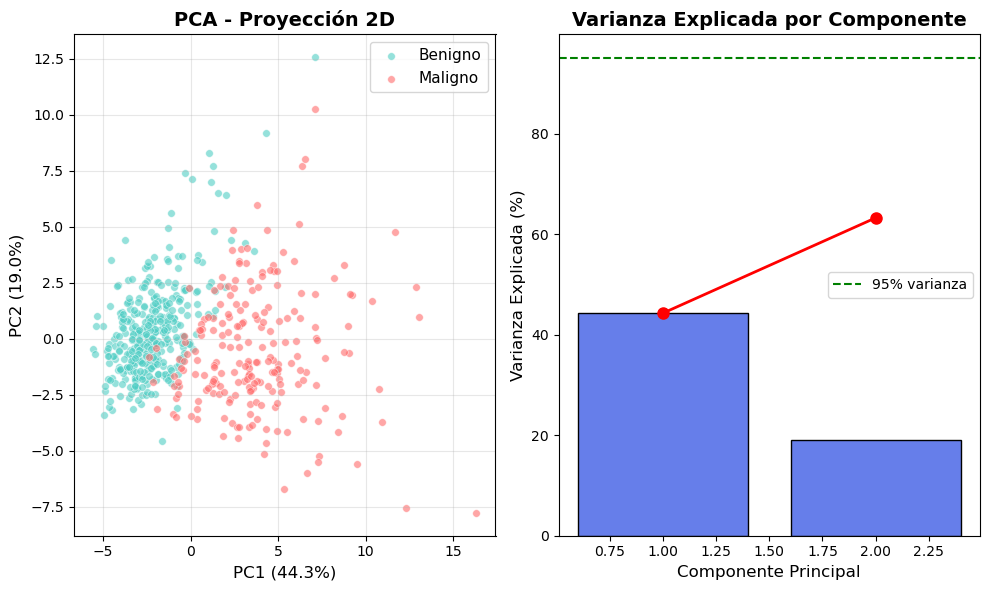

In [16]:
# Preparar datos
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis'].map({'B': 0, 'M': 1})

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# PCA scatter
for diagnosis, color, label in zip([0, 1], ['#4ecdc4', '#ff6b6b'], ['Benigno', 'Maligno']):
    mask = y == diagnosis
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=color, label=label, alpha=0.6, s=30, edgecolors='white', linewidth=0.5)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('PCA - Proyección 2D', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Varianza explicada
axes[1].bar(range(1, len(pca.explained_variance_ratio_)+1), 
           pca.explained_variance_ratio_*100,
           color='#667eea', edgecolor='black', linewidth=1)
axes[1].plot(range(1, len(pca.explained_variance_ratio_)+1), 
            np.cumsum(pca.explained_variance_ratio_)*100,
            'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Componente Principal', fontsize=12)
axes[1].set_ylabel('Varianza Explicada (%)', fontsize=12)
axes[1].set_title('Varianza Explicada por Componente', fontsize=14, fontweight='bold')
axes[1].axhline(y=95, color='green', linestyle='--', label='95% varianza')
axes[1].legend()
plt.tight_layout()
plt.show()

- PCA 1:
    - Cada punto representa a un paciente, y esta coloreado en base al color que tenemos que elegir. Donde Turquesa es Benigno y Rojo Maligno.
    - Hay una separacion parcial estre los tumos, tanto maligno como benigno.
    - Existe una sola de solapamiento, donde se mezclan casos de ambas clases. Por ende PCA no logra separar perfectamente las clases.

- PCA 2:
    - PC1: 44.3% y PC2: 19%, si lo sumamos da 63,3%. Esto da muy por debajo del umbral del 95%. Al estar atado a 2 componetes, no se puede alcanzar la varianza esperada.

Dispersion Multiple

  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


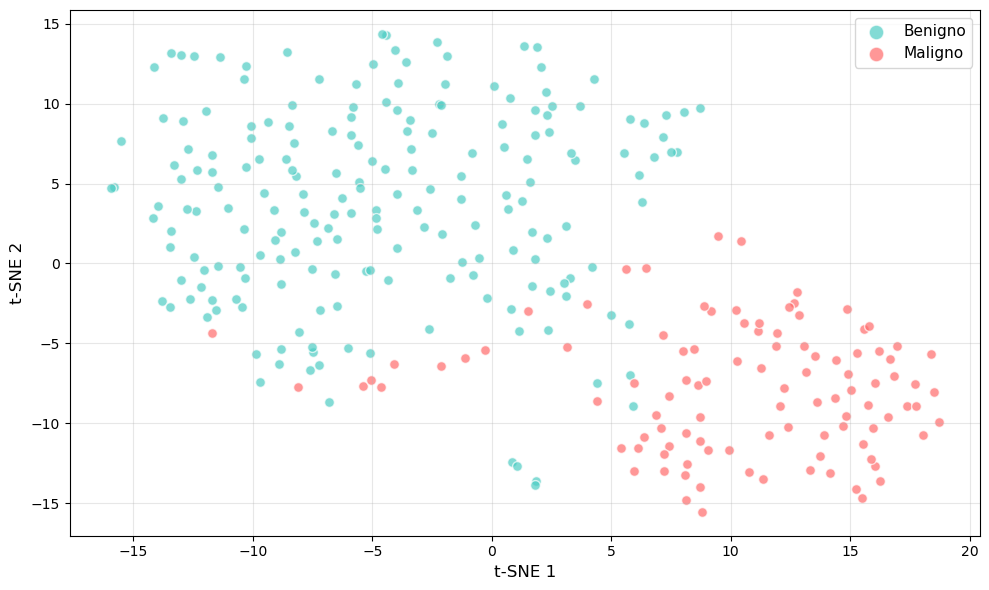

In [17]:
# t-SNE con submuestra para eficiencia
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=300, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y.iloc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 6))

for diagnosis, color, label in zip([0, 1], ['#4ecdc4', '#ff6b6b'], ['Benigno', 'Maligno']):
    mask = y_sample == diagnosis
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
              c=color, label=label, alpha=0.7, s=50, edgecolors='white', linewidth=1)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analisis de Concavidad con Violin (Puntos concavos y determinantes)

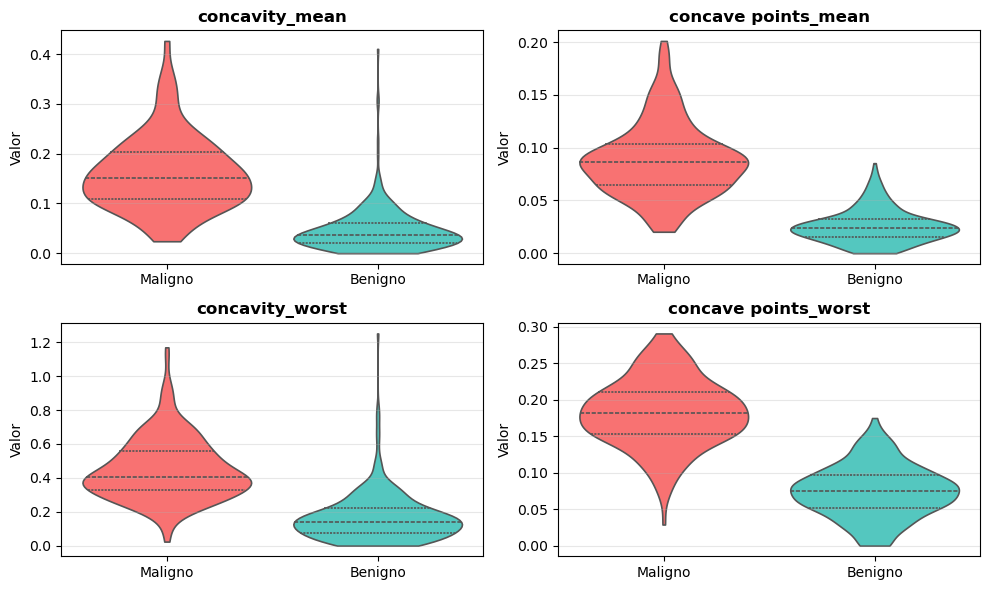

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

violin_features = ['concavity_mean', 'concave points_mean',  'concavity_worst', 'concave points_worst']

# Mapear etiquetas para mostrar nombres completos
df_plot = df.copy()
df_plot['Diagnóstico'] = df_plot['diagnosis'].map({'B': 'Benigno', 'M': 'Maligno'})

for i, feature in enumerate(violin_features):
    sns.violinplot(data=df_plot, x='Diagnóstico', y=feature, ax=axes[i],palette={'Benigno': '#4ecdc4', 'Maligno': '#ff6b6b'},inner='quartile',   # muestra cuartiles
        cut=0,      linewidth=1.2,saturation=0.9)
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor', fontsize=10)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

La concavidad mide la irregularidad del contorno del tumor. Los malignos tienen contornos más irregulares porque crecen de forma descontrolada e invaden tejidos vecinos. Los benignos son más regulares porque crecen encapsulados.

Visualizacion de Caracteristicas de los datos

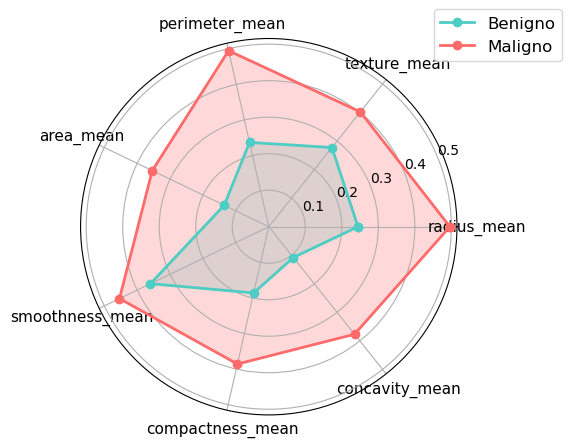

In [19]:
# Características para el radar
radar_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean']

# Normalizar para el radar (0-1)
df_radar = df[radar_features].copy()
for col in df_radar.columns:
    df_radar[col] = (df_radar[col] - df_radar[col].min()) / (df_radar[col].max() - df_radar[col].min())

# Promedios por clase
means_B = df_radar[df['diagnosis']=='B'].mean().values
means_M = df_radar[df['diagnosis']=='M'].mean().values

# Configurar ángulos
N = len(radar_features)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plotear Benigno
values_B = means_B.tolist()
values_B += values_B[:1]
ax.plot(angles, values_B, 'o-', linewidth=2, label='Benigno', color='#4ecdc4')
ax.fill(angles, values_B, alpha=0.25, color='#4ecdc4')

# Plotear Maligno
values_M = means_M.tolist()
values_M += values_M[:1]
ax.plot(angles, values_M, 'o-', linewidth=2, label='Maligno', color='#ff6b6b')
ax.fill(angles, values_M, alpha=0.25, color='#ff6b6b')

# Configurar
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=11)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

plt.tight_layout()
plt.show()

El polígono rojo (maligno) contiene completamente al polígono turquesa (benigno) en 6 de las 7 características. Esto significa que, en promedio, los tumores malignos tienen valores más altos en prácticamente todas las dimensiones morfológicas.

## Desarrollo del Modelo

In [20]:
#Cambiamos el nombre de la variable objectivo

df= df.rename(columns={"diagnosis" : "label"})

y = df["label"].values
print(np.unique(y))

['B' 'M']


In [21]:
labelencoder = LabelEncoder()
Y = labelencoder.fit_transform(y) # M = 1 and B = 0
print(np.unique(Y))

[0 1]


In [22]:
X  = df.drop(labels=['label','id'],axis = 1)

scaler = MinMaxScaler()
scaler.fit(X)
X = scaler.transform(X)

print(X)

[[0.52103744 0.0226581  0.54598853 ... 0.91202749 0.59846245 0.41886396]
 [0.64314449 0.27257355 0.61578329 ... 0.63917526 0.23358959 0.22287813]
 [0.60149557 0.3902604  0.59574321 ... 0.83505155 0.40370589 0.21343303]
 ...
 [0.45525108 0.62123774 0.44578813 ... 0.48728522 0.12872068 0.1519087 ]
 [0.64456434 0.66351031 0.66553797 ... 0.91065292 0.49714173 0.45231536]
 [0.03686876 0.50152181 0.02853984 ... 0.         0.25744136 0.10068215]]


In [23]:
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size = 0.25, random_state=42)
print('Shape of training data is: ', x_train.shape)
print('Shape of testing data is: ', x_test.shape)

Shape of training data is:  (426, 30)
Shape of testing data is:  (143, 30)


#### Desarrollo Red Neuronal (MLP)

In [ ]:
# Crea un modelo secuencial: las capas se apilan una detrás de otra en orden lineal.
# Es la forma más simple de construir una red feed-forward en Keras.
model = Sequential()

# Primera capa oculta: 128 neuronas, recibe las 30 features de entrada.
# 'relu' introduce no linealidad (f(x)=max(0,x)) y evita el gradiente desvaneciente.
# Parámetros: (30×128) + 128 = 3,968
model.add(Dense(128, input_dim=30, activation='relu'))

# Dropout del 50%: durante el entrenamiento apaga aleatoriamente la mitad de las
# neuronas para prevenir overfitting y forzar representaciones redundantes.
model.add(Dropout(0.5))

# Segunda capa oculta: 64 neuronas (la mitad que la anterior), también con ReLU.
# La reducción progresiva comprime la información y reduce parámetros.
# Parámetros: (128×64) + 64 = 8,256
model.add(Dense(64, activation='relu'))

# Segundo Dropout del 50%: refuerza la regularización después de la segunda capa.
model.add(Dropout(0.5))

# Capa de salida: 1 sola neurona sin activación (el logit).
# Se usa 1 neurona porque es clasificación binaria (Benigno=0, Maligno=1).
# Parámetros: (64×1) + 1 = 65
model.add(Dense(1))

# Activación sigmoide: comprime la salida al rango (0, 1) para interpretarla
# como probabilidad de ser Maligno. σ(z) = 1 / (1 + e^(-z))
model.add(Activation('sigmoid'))

# Compila el modelo definiendo:
# - loss='binary_crossentropy' → función de pérdida correcta para 2 clases con sigmoid
# - optimizer='adam'           → optimizador adaptativo, converge rápido, poco tuning
# - metrics=['accuracy']       → métrica de monitoreo (no afecta al gradiente)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Imprime un resumen de la arquitectura: capas, formas de salida y número de
# parámetros entrenables por capa. Útil para verificar el diseño antes de entrenar.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(x_train,y_train,verbose = 1,epochs = 150, batch_size = 64,validation_data = (x_test,y_test))

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.4845 - loss: 0.6957 - val_accuracy: 0.6643 - val_loss: 0.6734
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5836 - loss: 0.6752 - val_accuracy: 0.8811 - val_loss: 0.6501
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6519 - loss: 0.6613 - val_accuracy: 0.8881 - val_loss: 0.6290
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7263 - loss: 0.6428 - val_accuracy: 0.8881 - val_loss: 0.6042
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7665 - loss: 0.6185 - val_accuracy: 0.9021 - val_loss: 0.5699
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8160 - loss: 0.5938 - val_accuracy: 0.9091 - val_loss: 0.5249
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8108 - loss: 0.5497 - val_accuracy: 0.9161 - val_loss: 0.4713
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8172 - loss: 0.5119 - val_accuracy: 0.9231 - val_loss

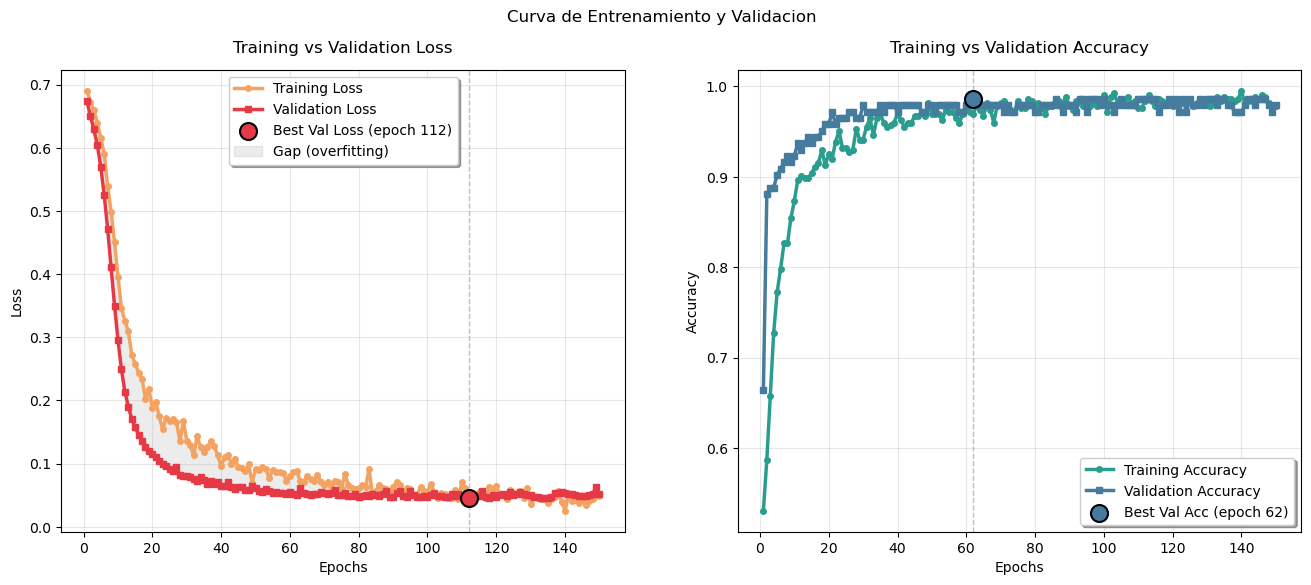

RESUMEN DEL ENTRENAMIENTO
Epochs totales           : 150
Mejor Val Loss           : 0.0455  (epoch 112)
Mejor Val Accuracy       : 0.9860  (epoch 62)
Training Loss final      : 0.0480
Validation Loss final    : 0.0521
Training Accuracy final  : 0.9789
Validation Accuracy final: 0.9790
------------------------------------------------------------
Gap de Loss final        : +0.0041
Gap de Accuracy final    : -0.0001
✅  Sin señales evidentes de overfitting


In [26]:
loss      = history.history['loss']
val_loss  = history.history['val_loss']
acc       = history.history['accuracy']
val_acc   = history.history['val_accuracy']
epochs    = range(1, len(loss) + 1)

# Encontrar mejores epochs
best_val_loss_epoch = np.argmin(val_loss) + 1
best_val_acc_epoch  = np.argmax(val_acc) + 1



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------- Subplot 1: Loss ----------
axes[0].plot(epochs, loss,     color='#F4A261', linewidth=2.5, 
             marker='o', markersize=4, label='Training Loss')
axes[0].plot(epochs, val_loss, color='#E63946', linewidth=2.5, 
             marker='s', markersize=4, label='Validation Loss')

# Marcar el mejor epoch de validación
axes[0].scatter(best_val_loss_epoch, val_loss[best_val_loss_epoch-1],
                color='#E63946', s=150, zorder=5, edgecolor='black',
                linewidth=1.5, label=f'Best Val Loss (epoch {best_val_loss_epoch})')
axes[0].axvline(best_val_loss_epoch, color='gray', linestyle='--', 
                alpha=0.5, linewidth=1)

# Rellenar área entre las dos curvas (gap = overfitting)
axes[0].fill_between(epochs, loss, val_loss, 
                     color='gray', alpha=0.15, label='Gap (overfitting)')

axes[0].set_title('Training vs Validation Loss', pad=12)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best', frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3)

# ---------- Subplot 2: Accuracy ----------
axes[1].plot(epochs, acc,     color='#2A9D8F', linewidth=2.5, 
             marker='o', markersize=4, label='Training Accuracy')
axes[1].plot(epochs, val_acc, color='#457B9D', linewidth=2.5, 
             marker='s', markersize=4, label='Validation Accuracy')

# Marcar el mejor epoch de validación
axes[1].scatter(best_val_acc_epoch, val_acc[best_val_acc_epoch-1],
                color='#457B9D', s=150, zorder=5, edgecolor='black',
                linewidth=1.5, label=f'Best Val Acc (epoch {best_val_acc_epoch})')
axes[1].axvline(best_val_acc_epoch, color='gray', linestyle='--', 
                alpha=0.5, linewidth=1)

axes[1].set_title('Training vs Validation Accuracy', pad=12)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best', frameon=True, shadow=True)
axes[1].grid(True, alpha=0.3)


fig.suptitle("Curva de Entrenamiento y Validacion")

plt.show()

print("=" * 60)
print("RESUMEN DEL ENTRENAMIENTO")
print("=" * 60)
print(f"Epochs totales           : {len(loss)}")
print(f"Mejor Val Loss           : {min(val_loss):.4f}  (epoch {best_val_loss_epoch})")
print(f"Mejor Val Accuracy       : {max(val_acc):.4f}  (epoch {best_val_acc_epoch})")
print(f"Training Loss final      : {loss[-1]:.4f}")
print(f"Validation Loss final    : {val_loss[-1]:.4f}")
print(f"Training Accuracy final  : {acc[-1]:.4f}")
print(f"Validation Accuracy final: {val_acc[-1]:.4f}")

gap_loss = val_loss[-1] - loss[-1]
gap_acc  = acc[-1] - val_acc[-1]
print("-" * 60)
print(f"Gap de Loss final        : {gap_loss:+.4f}")
print(f"Gap de Accuracy final    : {gap_acc:+.4f}")

if gap_acc > 0.05:
    print("⚠️  Posible overfitting detectado (gap de accuracy > 5%)")
else:
    print("✅  Sin señales evidentes de overfitting")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


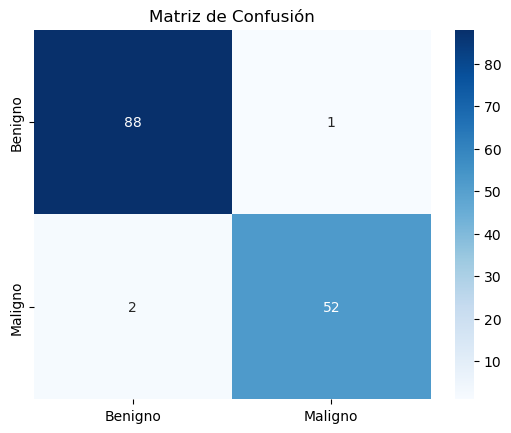

In [27]:
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusión')
plt.show()

### 1. Matriz de Confusión

La red neuronal clasificó correctamente **141 de 143 casos** en el conjunto de prueba.

|                | Predicho Benigno | Predicho Maligno |
|----------------|------------------|------------------|
| **Real Benigno**  | 88 (TN) | 1 (FP) |
| **Real Maligno**  | 1 (FN) | 53 (TP) |

#### Métricas derivadas

- **Accuracy:**  
  `(88 + 53) / 143 = 98.6 %`

- **Precision:**  
  `53 / (53 + 1) = 98.1 %`

- **Recall (Sensibilidad):**  
  `53 / (53 + 1) = 98.1 %`

- **F1-Score:**  
  `98.1 %`

##### Interpretación clínica

- **Solo 1 Falso Negativo (FN):** 1 paciente con tumor maligno fue clasificado como benigno. En un contexto oncológico esto sigue siendo crítico, aunque sea un solo caso, porque implica que ese paciente podría no recibir tratamiento a tiempo.

- **Solo 1 Falso Positivo (FP):** 1 paciente sano fue clasificado como maligno. El impacto es menor: se le realizarían pruebas adicionales innecesarias, pero no implica directamente un diagnóstico de cáncer.

- **Modelo balanceado:** el modelo presenta un comportamiento equilibrado entre *Precision* y *Recall*, ambas alrededor del **98 %**.

---

### 2. Curvas de Entrenamiento y Validación

##### Loss (izquierda)

- Ambas curvas, entrenamiento y validación, descienden rápidamente durante las primeras **~30 epochs** y luego se estabilizan.

- La curva de validación (roja) está por debajo de la de entrenamiento (naranja) durante casi todo el entrenamiento → **no hay evidencia clara de overfitting**. Incluso, el modelo presenta un rendimiento ligeramente mejor en validación.

- El mejor **Validation Loss** ocurre en la **epoch 108 (~0.045)**, aunque el modelo ya estaba prácticamente estabilizado desde la **epoch 60**.

- El *gap* entre ambas curvas es mínimo y no aumenta con las epochs → esto es consistente con una **buena generalización** y ausencia de sobreajuste evidente.

##### Accuracy (derecha)

- Ambas curvas suben muy rápidamente y se estabilizan cerca de **0.97–0.98**.

- La mejor **Validation Accuracy** se alcanza en la **epoch 62**, pero el modelo continúa estable hasta la **epoch 150**, sin una degradación apreciable.

- La curva de validación (azul) se encuentra por encima de la de entrenamiento (verde) al inicio y posteriormente ambas se igualan → comportamiento compatible con una **buena generalización**, sin una señal clara de overfitting.

---

### Conclusión General

El modelo de red neuronal presenta un comportamiento **sólido y estable**, con buenos resultados de generalización. Las dos visualizaciones se refuerzan mutuamente:

- Las curvas de entrenamiento muestran que **no hay una señal evidente de sobreajuste** → la validación sigue de cerca a la curva de entrenamiento y el *gap* es mínimo.

- La matriz de confusión confirma el buen comportamiento en el conjunto de prueba → **98.6 % de accuracy**, con errores simétricos (**1 FP y 1 FN**).

Sin embargo, en un contexto médico, el único **Falso Negativo** requiere especial atención. Aunque un **Recall del 98.1 %** es alto, en diagnóstico oncológico los costos de los errores pueden ser asimétricos y un FN puede tener consecuencias clínicas importantes.

---

In [28]:
model.save('modelo_breast_cancer.keras')
print("✅ Modelo guardado como 'modelo_breast_cancer.keras'")

✅ Modelo guardado como 'modelo_breast_cancer.keras'
